# Task 2: Descriptive Transactional Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading cleaned dataset from Task 1
df = pd.read_csv("../data/goldman_sachs_cleaned.csv")

# Converting TransactionDate back to datetime
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

# Creating useful date columns
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month
df["YearMonth"] = df["TransactionDate"].dt.to_period("M")

In [2]:
# Classifying Credit and Debit Transactions

credit_types = ["Deposit"]
debit_types = ["Withdrawal", "Payment", "Transfer"]

df["FlowType"] = np.where(
    df["TransactionType"].isin(credit_types),
    "Credit",
    "Debit"
)

df[["TransactionType", "FlowType"]].head()

,TransactionType,FlowType
0,Withdrawal,Debit
1,Withdrawal,Debit
2,Deposit,Credit
3,Withdrawal,Debit
4,Withdrawal,Debit


In [3]:
# Calculating Monthly Transaction Summary

monthly_summary = (
    df.groupby(["YearMonth", "FlowType"])["TransactionAmount"]
      .sum()
      .unstack(fill_value=0)
)

# Ensuring both columns exist
monthly_summary = monthly_summary.reindex(
    columns=["Credit", "Debit"],
    fill_value=0
)

monthly_summary["Net Inflow"] = (
    monthly_summary["Credit"] -
    monthly_summary["Debit"]
)

monthly_summary["Total Volume"] = (
    monthly_summary["Credit"] +
    monthly_summary["Debit"]
)

pd.options.display.float_format = '{:,.2f}'.format

monthly_summary

FlowType,Credit,Debit,Net Inflow,Total Volume
YearMonth,,,,
2023-01,"762,099.56","2,380,984.30","-1,618,884.74","3,143,083.86"
2023-02,"648,261.00","1,436,501.75","-788,240.74","2,084,762.75"
2023-03,"604,002.42","2,098,983.35","-1,494,980.93","2,702,985.77"
2023-04,"439,321.69","1,338,294.29","-898,972.60","1,777,615.98"
2023-05,"425,589.87","2,203,715.27","-1,778,125.40","2,629,305.14"
2023-06,"469,388.81","899,643.22","-430,254.42","1,369,032.03"
2023-07,"648,027.88","951,395.68","-303,367.80","1,599,423.56"
2023-08,"544,970.36","2,011,231.54","-1,466,261.18","2,556,201.91"
2023-09,"712,838.80","1,612,681.10","-899,842.30","2,325,519.89"


# Monthly Transaction Summary

The transaction data was grouped by Year-Month and Flow Type (Credit/Debit). For each month, the total credit amount, total debit amount, 
net inflow (Credit − Debit), and total transaction volume (Credit + Debit) were calculated.

This analysis helps identify monthly transaction patterns, cash flow trends, and periods of unusually high financial activity.



In [4]:
yearly_summary = (
    df.groupby(["Year", "FlowType"])["TransactionAmount"]
      .sum()
      .unstack(fill_value=0)
)

# Ensuring both columns exist
yearly_summary = yearly_summary.reindex(
    columns=["Credit", "Debit"],
    fill_value=0
)

# Calculating Net Inflow
yearly_summary["Net Inflow"] = (
    yearly_summary["Credit"] -
    yearly_summary["Debit"]
)

# Calculating Total Transaction Volume
yearly_summary["Total Volume"] = (
    yearly_summary["Credit"] +
    yearly_summary["Debit"]
)

yearly_summary

FlowType,Credit,Debit,Net Inflow,Total Volume
Year,,,,
2023,"7,285,848.74","21,399,946.34","-14,114,097.60","28,685,795.08"
2024,"3,311,426.12","9,801,039.41","-6,489,613.29","13,112,465.54"


# Yearly Transaction Summary

The transaction data was aggregated at the yearly level to analyze the overall financial activity across different years.

The following metrics were calculated:

- Total Credit Amount
- Total Debit Amount
- Net Inflow (Credit − Debit)
- Total Transaction Volume (Credit + Debit)

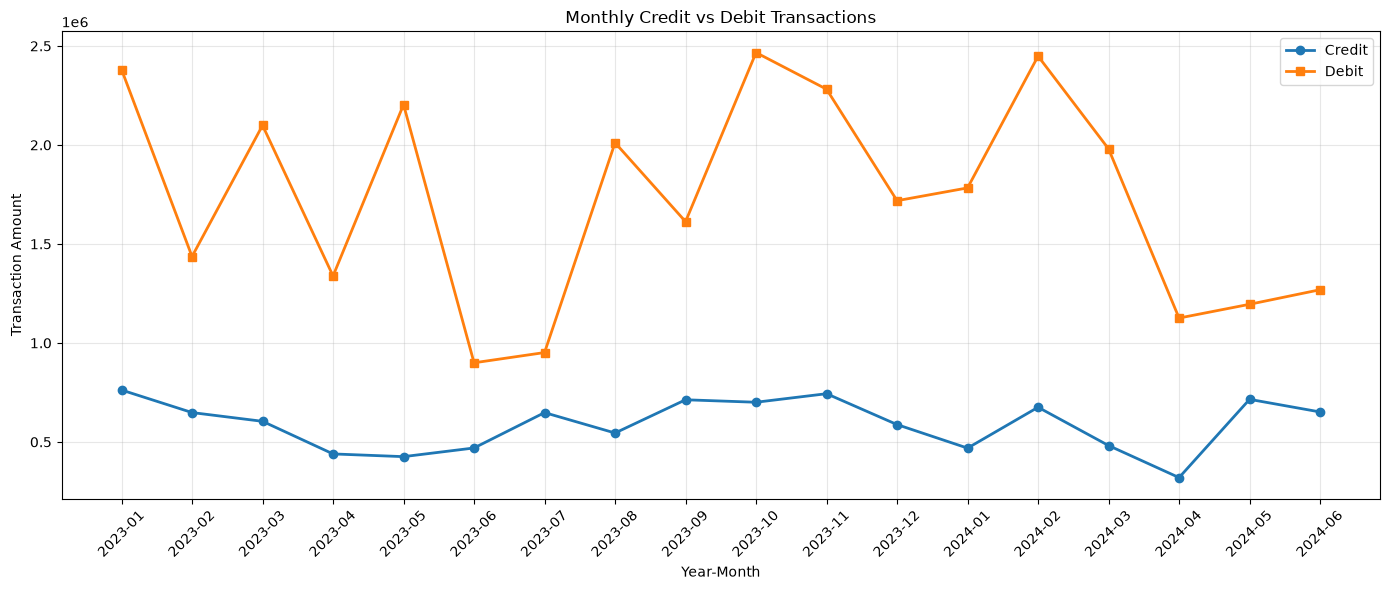

In [5]:
# Plotting Monthly Credit vs Debit Trend

plt.figure(figsize=(14,6))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Credit"],
    marker="o",
    linewidth=2,
    label="Credit"
)

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["Debit"],
    marker="s",
    linewidth=2,
    label="Debit"
)

plt.title("Monthly Credit vs Debit Transactions")
plt.xlabel("Year-Month")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Monthly Credit vs Debit Trend

The line chart was created to compare monthly credit and debit transaction amounts over time.

This visualization helps identify changes in customer transaction behaviour, seasonal variations, and differences between incoming and 
outgoing cash flow.

The trend can assist management in identifying periods of increased financial activity and monitoring overall transaction performance.

In [6]:
# Calculating the net cash inflow for each account

account_summary = (
    df.groupby(["AccountID", "FlowType"])["TransactionAmount"]
      .sum()
      .unstack(fill_value=0)
)

# Ensuring both columns exist
account_summary = account_summary.reindex(
    columns=["Credit", "Debit"],
    fill_value=0
)

# Calculating Net Inflow
account_summary["Net Inflow"] = (
    account_summary["Credit"] -
    account_summary["Debit"]
)

account_summary.head()

FlowType,Credit,Debit,Net Inflow
AccountID,,,
Acc10117,"142,170.20","57,310.76","84,859.44"
Acc10996,"62,580.86","188,158.69","-125,577.82"
Acc11062,0.00,"27,189.14","-27,189.14"
Acc11188,"45,748.34","211,828.26","-166,079.92"
Acc11285,0.00,"96,729.61","-96,729.61"


In [7]:
# Top 5 performing accounts 

top_accounts = account_summary.nlargest(5, "Net Inflow")

top_accounts

FlowType,Credit,Debit,Net Inflow
AccountID,,,
Acc48501,"346,856.34",0.00,"346,856.34"
Acc33287,"390,354.43","201,236.67","189,117.76"
Acc87006,"245,497.38","101,488.37","144,009.01"
Acc50817,"244,837.13","123,447.97","121,389.17"
Acc99117,"167,040.52","45,808.22","121,232.30"


In [8]:
# Top 5 underperforming accounts

bottom_accounts = account_summary.nsmallest(5, "Net Inflow")

bottom_accounts

FlowType,Credit,Debit,Net Inflow
AccountID,,,
Acc53466,"18,181.67","476,775.48","-458,593.81"
Acc29396,"39,888.00","442,832.01","-402,944.01"
Acc60432,"39,623.17","423,334.68","-383,711.52"
Acc29356,"27,344.62","408,228.87","-380,884.25"
Acc78178,"40,976.43","392,683.44","-351,707.01"


In [9]:
# Sorting the Transactions

df_sorted = df.sort_values(
    by=["AccountID", "TransactionDate"]
).copy()

df_sorted.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,IsOverdraft,Year,Month,YearMonth,FlowType
468,73,Cust9209,Acc10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,"57,310.76","79,464.39",0.35,354,60,False,2023,1,2023-01,Debit
25,34,Cust3109,Acc10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,"67,555.28","89,667.83",0.21,611,85,False,2023,2,2023-02,Credit
87,106,Cust8155,Acc10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,"63,248.56","31,961.53",0.74,573,109,False,2023,6,2023-06,Credit
742,169,Cust3810,Acc10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,"11,366.36","79,334.27",0.37,697,218,False,2024,3,2024-03,Credit
384,158,Cust3041,Acc10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,"11,989.50","45,731.50",0.75,557,233,False,2023,5,2023-05,Debit


In [10]:
# Fetching previous transaction dates

df_sorted["PreviousTransactionDate"] = (
    df_sorted.groupby("AccountID")["TransactionDate"]
             .shift(1)
)

df_sorted.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountBalance,RiskScore,CreditRating,TenureMonths,IsOverdraft,Year,Month,YearMonth,FlowType,PreviousTransactionDate
468,73,Cust9209,Acc10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,"79,464.39",0.35,354,60,False,2023,1,2023-01,Debit,NaT
25,34,Cust3109,Acc10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,"89,667.83",0.21,611,85,False,2023,2,2023-02,Credit,2023-01-30
87,106,Cust8155,Acc10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,"31,961.53",0.74,573,109,False,2023,6,2023-06,Credit,2023-02-21
742,169,Cust3810,Acc10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,"79,334.27",0.37,697,218,False,2024,3,2024-03,Credit,2023-06-18
384,158,Cust3041,Acc10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,"45,731.50",0.75,557,233,False,2023,5,2023-05,Debit,NaT


In [11]:
# Calculating the gap between transactions

df_sorted["DaysSinceLastTransaction"] = (
    df_sorted["TransactionDate"] -
    df_sorted["PreviousTransactionDate"]
).dt.days

df_sorted.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,IsOverdraft,Year,Month,YearMonth,FlowType,PreviousTransactionDate,DaysSinceLastTransaction
468,73,Cust9209,Acc10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,0.35,354,60,False,2023,1,2023-01,Debit,NaT,NaN
25,34,Cust3109,Acc10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,0.21,611,85,False,2023,2,2023-02,Credit,2023-01-30,22.00
87,106,Cust8155,Acc10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,0.74,573,109,False,2023,6,2023-06,Credit,2023-02-21,117.00
742,169,Cust3810,Acc10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,0.37,697,218,False,2024,3,2024-03,Credit,2023-06-18,270.00
384,158,Cust3041,Acc10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,0.75,557,233,False,2023,5,2023-05,Debit,NaT,NaN


In [12]:
# Flagging Dormant transactions

df_sorted["IsDormantGap"] = (
    df_sorted["DaysSinceLastTransaction"] >= 60
)

df_sorted.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,IsOverdraft,Year,Month,YearMonth,FlowType,PreviousTransactionDate,DaysSinceLastTransaction,IsDormantGap
468,73,Cust9209,Acc10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,354,60,False,2023,1,2023-01,Debit,NaT,NaN,False
25,34,Cust3109,Acc10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,611,85,False,2023,2,2023-02,Credit,2023-01-30,22.00,False
87,106,Cust8155,Acc10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,573,109,False,2023,6,2023-06,Credit,2023-02-21,117.00,True
742,169,Cust3810,Acc10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,697,218,False,2024,3,2024-03,Credit,2023-06-18,270.00,True
384,158,Cust3041,Acc10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,557,233,False,2023,5,2023-05,Debit,NaT,NaN,False


In [13]:
# Identifying doramant accounts

dormant_accounts = (
    df_sorted.loc[df_sorted["IsDormantGap"], "AccountID"]
    .unique()
)

print("Number of Dormant Accounts:", len(dormant_accounts))

Number of Dormant Accounts: 164


In [14]:
# Adding dormant flags to the dormant accounts in original dataset

df["IsDormantAccount"] = (
    df["AccountID"].isin(dormant_accounts)
)

df[["AccountID", "IsDormantAccount"]].head()

,AccountID,IsDormantAccount
0,Acc12334,True
1,Acc52650,True
2,Acc45101,True
3,Acc88252,True
4,Acc21878,True


In [15]:
# Displaying dormant accounts 

dormant_df = (
    df[df["IsDormantAccount"]]
    [["AccountID"]]
    .drop_duplicates()
)

print(dormant_df)

    AccountID
0    Acc12334
1    Acc52650
2    Acc45101
3    Acc88252
4    Acc21878
..        ...
452  Acc58078
480  Acc40952
551  Acc11062
569  Acc77592
592  Acc34119

[164 rows x 1 columns]


# Dormant Account Identification

To identify inactive accounts, the transaction history of each account was sorted chronologically.

The time gap between consecutive transactions was calculated, and accounts with a gap of 60 days or more (approximately two months)
were flagged as dormant.

Dormant account detection helps financial institutions identify inactive customers, monitor potential account abandonment, and develop 
customer re-engagement strategies.